# Local Vol Calibration (Section method)

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the calibration of a type of Local Vol models where the Local Vol is specified by a series of parametric functions at each expiry. The vanilla options are calculated by forward PDE and the parametric functions are calibrated by optimization on the PDE prices (not Dupire).

In [7]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.maths import metrics
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market.eqforward import get_forward_curves
from sdevpy.utilities import timegrids
from sdevpy.volatility.localvol.lvsection_calib import calibrate_lv_bysections
from sdevpy.volatility.localvol import localvol_factory as lvf
from sdevpy.volatility.impliedvol.numerical_impliedvol import NumericalImpliedVol
from sdevpy.pde.pdeschemes import PdeConfig
from sdevpy import logger
logger.configure(sdevpy_level='info')

print("SDevPy version: " + sd.__version__)

SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name, valdate = "ABC", dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

option_data.pretty_print()

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5
----------------------------------------------------------------------
----------------------------------------------------------------------
Name: ABC
Valuation date: 15-Dec-2025
Snap date: 15-Dec-2025 00:00:00
Strike input type: absolute
Number of expiries: 6
----------------------------------------------------------------------
Expiry 1/6: 20-Jan-2026
Strikes [ 90.2632  94.7008  99.8876 105.3584 110.5382]
Vols [0.3835 0.3258 0.276  0.2935 0.3268]
----------------------------------------------------------------------
Expiry 2/6: 16-Mar-2026
Strikes [ 84.9586  91.6

### Fit Local Vol Model
In this section we choose and fit an implied vol model, and then display the accuracy of the fit against the market data.

In [3]:
# Choose model
section_model = 'BiExp' # SVI, CubicVol, BiExp

# Calibration config (COBYLA, SLSQP, LeastSquares)
config = {'model_name': section_model, 'store_date': valdate, 'pde_timesteps': 100, 'pde_spotsteps': 250,
          'optimizer': 'LeastSquares', 'maxiter': 100, 'force_restart': True, 'sol_as_init': True}

# Calibrate LV
print("Launching calibration")
calib_result = calibrate_lv_bysections(valdate, name, config, calc_pde_vols=True)
lv = calib_result['lv']
print("Calibration done")

INFO | Initializing new LV for ABC
INFO | Val date: 15-Dec-2025
INFO | Model: BiExp
INFO | PDE time steps: 100
INFO | PDE spot steps: 250
INFO | Optimizer: LeastSquares
INFO | --------------------------------------------------
INFO | Optimizing at expiry: 0/6
INFO | Initial params: [0.25      0.3       0.28      0.0065428 0.0032714 0.       ]


INFO | Bounds: Bounds(array([ 0.01,  0.01,  0.01,  0.01,  0.01, -2.  ]), array([1., 1., 1., 2., 2., 2.]))


Launching calibration


INFO | Result x: [ 0.21872259  0.98608493  0.54009036  0.05889287  0.04049809 -0.2179456 ]
INFO | RMSE(prices): 0.0000
INFO | Number evals: 427
INFO | --------------------------------------------------
INFO | Optimizing at expiry: 1/6
INFO | Initial params: [ 0.21872259  0.98608493  0.54009036  0.05889287  0.04049809 -0.2179456 ]
INFO | Bounds: Bounds(array([ 0.01,  0.01,  0.01,  0.01,  0.01, -2.  ]), array([1., 1., 1., 2., 2., 2.]))
INFO | Result x: [ 0.22585458  0.41190309  0.34629839  0.06815121  0.05529441 -0.06965908]
INFO | RMSE(prices): 0.0000
INFO | Number evals: 227
INFO | --------------------------------------------------
INFO | Optimizing at expiry: 2/6
INFO | Initial params: [ 0.22585458  0.41190309  0.34629839  0.06815121  0.05529441 -0.06965908]
INFO | Bounds: Bounds(array([ 0.01,  0.01,  0.01,  0.01,  0.01, -2.  ]), array([1., 1., 1., 2., 2., 2.]))
INFO | Result x: [0.24495802 0.35266058 0.3422658  0.0965856  0.13117004 0.0402603 ]
INFO | RMSE(prices): 0.0000
INFO | Numb

Calibration done


### Diagnostics
Compare PDE implied vols vs market and look at the shape of the optimum local vols.

Num. IV vols: [array([0.37937588, 0.32256973, 0.27322304, 0.28991938, 0.32324475]), array([0.33741501, 0.30284897, 0.27490279, 0.28103635, 0.29938919]), array([0.31571967, 0.29294819, 0.27514754, 0.27674615, 0.28777164]), array([0.30154212, 0.28676232, 0.27593751, 0.27491166, 0.28091313]), array([0.29238273, 0.2826844 , 0.27574711, 0.2741255 , 0.27687279]), array([0.28537935, 0.28023572, 0.27607895, 0.2744134 , 0.27469344])]


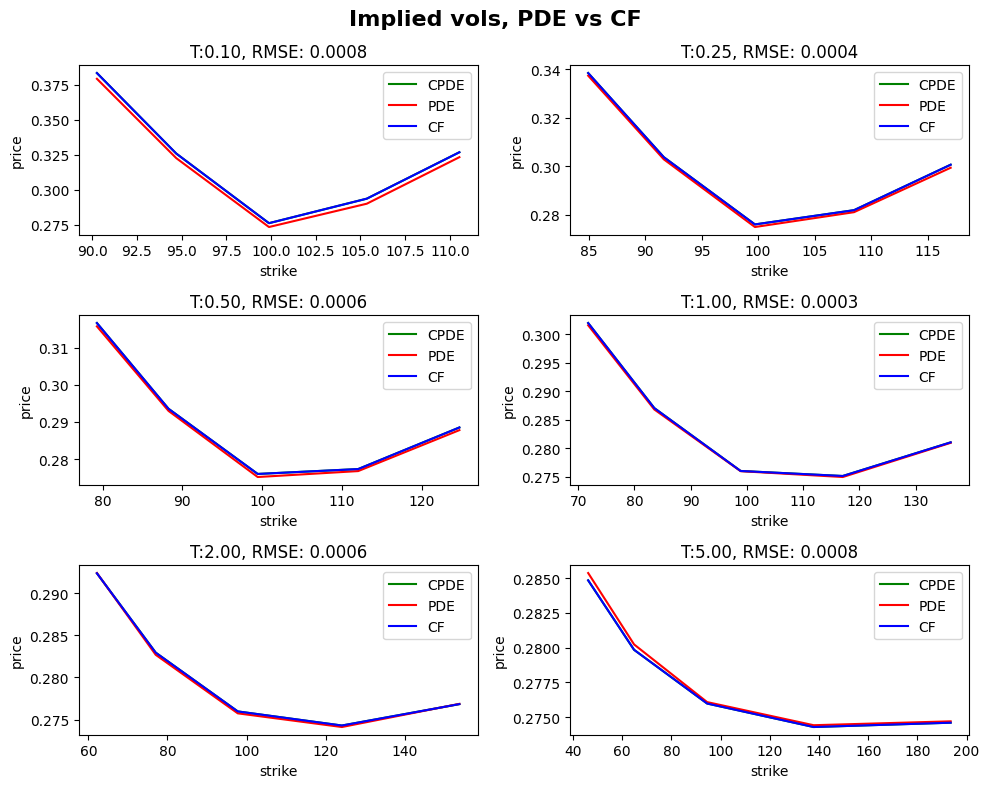

Params at 0.099, [ 0.21872259  0.98608493  0.54009036  0.05889287  0.04049809 -0.2179456 ]
Params at 0.249, [ 0.22585458  0.41190309  0.34629839  0.06815121  0.05529441 -0.06965908]
Params at 0.499, [0.24495802 0.35266058 0.3422658  0.0965856  0.13117004 0.0402603 ]
Params at 1.000, [ 0.25970163  0.38077932  0.38971017  0.28144825  0.35603916 -0.02811238]
Params at 2.000, [ 0.26573717  0.37963488  0.35667902  0.58258298  0.62370735 -0.01422783]
Params at 5.003, [ 0.27011763  0.29223183  0.27366883  0.40500977  0.1635577  -0.0099123 ]


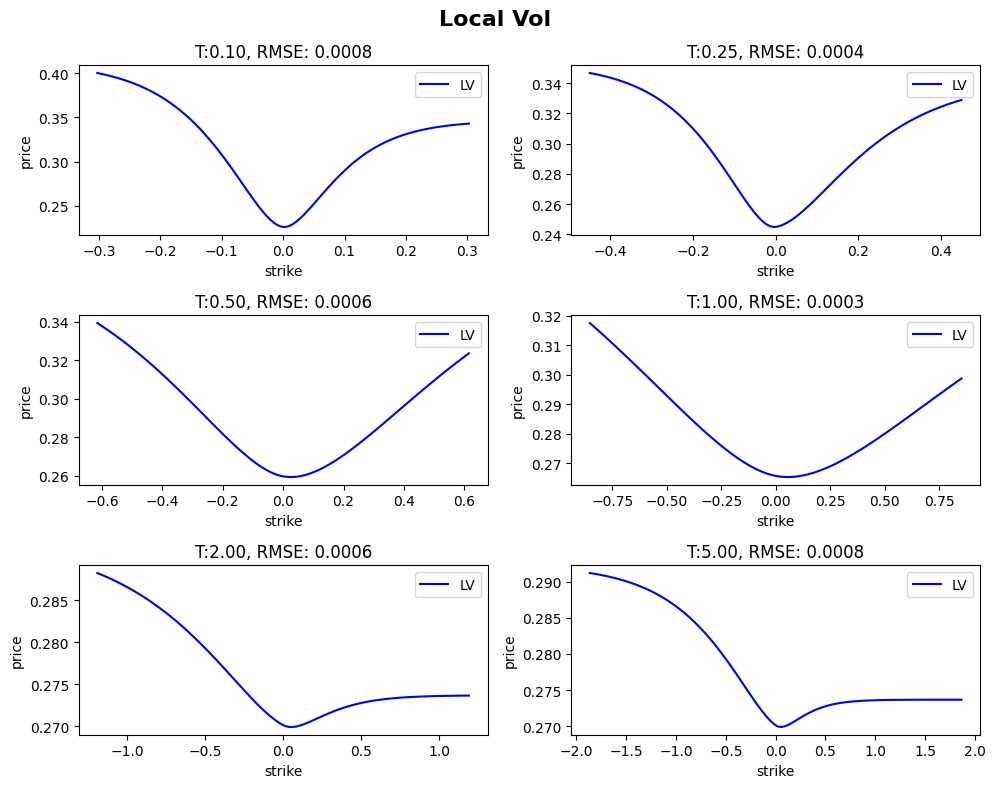

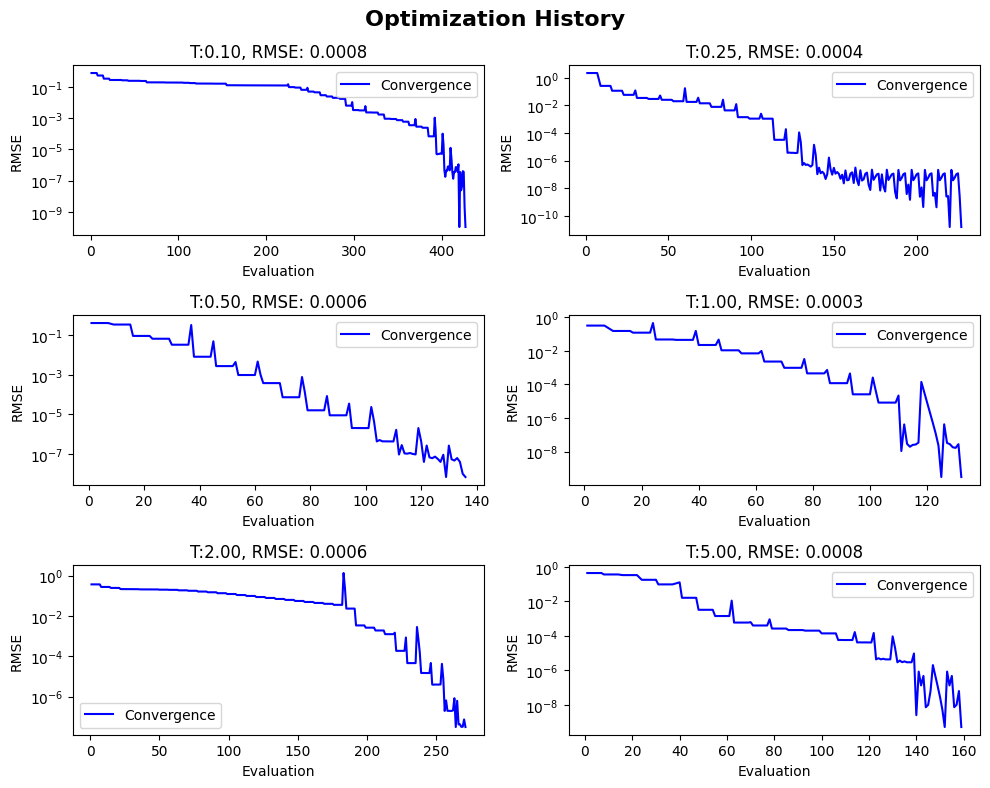

In [6]:
# ################ DIAGNOSTICS ################################################################
# Retrieve results for diagnostics
calib_pde_vols = calib_result['pde_vols'] # PDE vols from calibration
surface_data = calib_result['iv_data'] # Get from inputs instead? Better check.
expiries = surface_data.expiries
expiry_grid = np.array([timegrids.model_time(valdate, expiry) for expiry in expiries])

# pde_config = DFLT_PDE_CONFIG
pde_config = PdeConfig(n_timesteps=500, n_meshes=500, scheme='Rannacher')
num_iv = NumericalImpliedVol(lv, pde_config=pde_config)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]
fwds = fwd_curve.value(expiries)
strike_surface = surface_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
vol_surface = surface_data.vols

# Calculate RMSEs on vols
calib_vol_rmses = []
is_call = True
num_iv_vols = []
for exp_idx, expiry in enumerate(expiry_grid):
    calib_vol_rmses.append(10000.0 * metrics.rmse(vol_surface[exp_idx], calib_pde_vols[exp_idx]))
    f = fwds[exp_idx]
    strikes = strike_surface[exp_idx]
    num_iv_vols.append(num_iv.black_volatility(expiry, strikes, f))

print(f"Num. IV vols: {num_iv_vols}")

# Display implied vol results
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        strikes = strike_surface[exp_idx]
        ax.plot(strikes, calib_pde_vols[exp_idx], label="CPDE", color='green')
        ax.plot(strikes, num_iv_vols[exp_idx], label="PDE", color='red')
        ax.plot(strikes, vol_surface[exp_idx], label="CF", color='blue')
        ax.set_title(f"T:{expiry_grid[exp_idx]:.2f}, RMSE: {calib_vol_rmses[exp_idx]:.4f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('price')
        ax.legend()

fig.suptitle('Implied vols, PDE vs CF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display LV results
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = expiry_grid[exp_idx]
        vol = vol_surface[exp_idx].mean()
        stdev = vol * np.sqrt(expiry)
        print(f"Params at {expiry:.3f}, {lv.params(exp_idx)}")
        xs = np.linspace(-3.0 * stdev, 3.0 * stdev, 100)
        lvs = lv.value(expiry, xs)
        ax.plot(xs, lvs, label="LV", color='blue')
        ax.set_title(f"T:{expiry:.2f}, RMSE: {calib_vol_rmses[exp_idx]:.4f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('price')
        ax.legend()

fig.suptitle('Local Vol', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display optimization history
history = calib_result['history']
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = expiry_grid[exp_idx]
        exp_history = history[exp_idx]
        ax.plot(exp_history['evals'], exp_history['rmses'], label="Convergence", color='blue')
        ax.set_title(f"T:{expiry:.2f}, RMSE: {calib_vol_rmses[exp_idx]:.4f}")
        ax.set_yscale('log')
        ax.set_xlabel('Evaluation')
        ax.set_ylabel('RMSE')
        ax.legend()

fig.suptitle('Optimization History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Dump to file
out_file = lvf.data_file(name, valdate, config['model_name'])
print(f"Dumping LV result to file: {out_file}")
lv.dump(out_file)

Dumping LV result to file: C:\Code\SDev.Python\datasets\localvol\ABC\20251215-000000.BiExp.json
